# 01. Three-phase telemetry and the harmonic sequence view

What I have is a short burst of three-phase telemetry from a grid-connected
battery: the instantaneous phase voltages and currents, sampled fast enough to
resolve the 50 Hz fundamental many times over. Across these two notebooks I want
to read that record as a sum of *symmetrical sequence* components, the balanced
sets that add back up to the measured phases, and watch those components move as
the event unfolds.

This notebook sets the scene with the raw waveforms, then takes the harmonic
route to the sequence content: group the spectrum into integer harmonics of the
fundamental and label each by the sequence it belongs to in a balanced system.
Notebook 02 takes the cleaner per-cycle phasor route, and that is the one to
trust when the numbers matter.

The sliding-window decomposition is computed in
`scripts/run_sequence_analysis.py` and read back here from `artifacts/`. This
notebook only loads results and draws them.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from seqanalysis.io import load_telemetry
from seqanalysis.plotting import palette, plot_sequence_series, save_figure, setup_style


def project_root() -> Path:
    """Locate the project root whether run from the repo or the notebooks dir."""
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "seqanalysis").exists():
            return parent
    return Path.cwd()


setup_style()
ROOT = project_root()
ARTIFACTS = ROOT / "artifacts"
telemetry = load_telemetry(ROOT / "data" / "raw" / "BigBatt_telem.csv")
meta = json.loads((ARTIFACTS / "meta.json").read_text())
frame = telemetry.frame
frame.head()

,time_s,Va,Vb,Vc,Ia,Ib,Ic
0,0.000000,4191.884766,-9154.736328,4949.256348,0.805699,-1.464620,0.658635
1,0.000611,5624.489746,-9131.511719,3484.362549,0.146491,-0.585819,0.585389
2,0.001222,6579.559570,-8469.873047,1864.255859,0.146491,-0.073245,0.000000
3,0.001833,7484.213867,-7611.103516,119.525368,0.732453,-0.219736,-0.365940
4,0.002444,8328.822266,-6660.564941,-1675.620972,1.171925,-0.439472,-0.585389


## The raw waveforms

The record is about a second long, sampled near 1.6 kHz, so each 50 Hz cycle
carries roughly thirty samples. Over the full span the three phase voltages
trace the familiar balanced trio, but look at the envelope: it is not flat. The
amplitudes drift over the event, and that drift is exactly the imbalance the
sequence decomposition is meant to quantify.

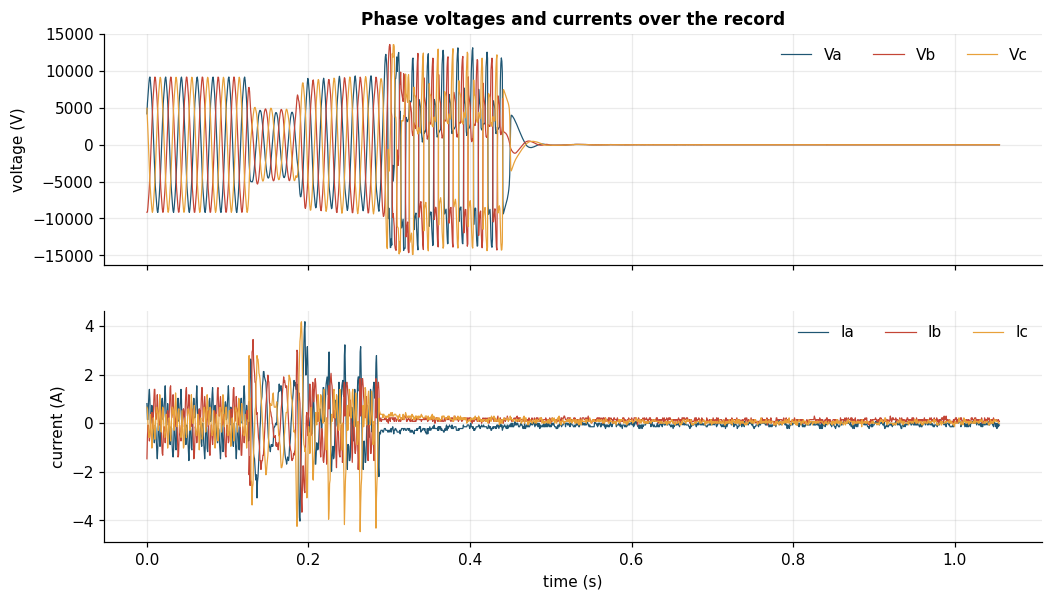

In [2]:
fig, (ax_v, ax_i) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for column in ("Va", "Vb", "Vc"):
    ax_v.plot(frame["time_s"], frame[column], color=palette(column), lw=0.8, label=column)
for column in ("Ia", "Ib", "Ic"):
    ax_i.plot(frame["time_s"], frame[column], color=palette(column), lw=0.8, label=column)
ax_v.set_ylabel("voltage (V)")
ax_v.set_title("Phase voltages and currents over the record")
ax_v.legend(ncol=3, loc="upper right")
ax_i.set_ylabel("current (A)")
ax_i.set_xlabel("time (s)")
ax_i.legend(ncol=3, loc="upper right")
plt.show()

A single cycle makes the phase relationship clear: three sinusoids of equal
amplitude spaced 120 degrees apart, give or take the imbalance we are about to
measure. One cycle is also the natural analysis window, the shortest span that
still resolves the fundamental.

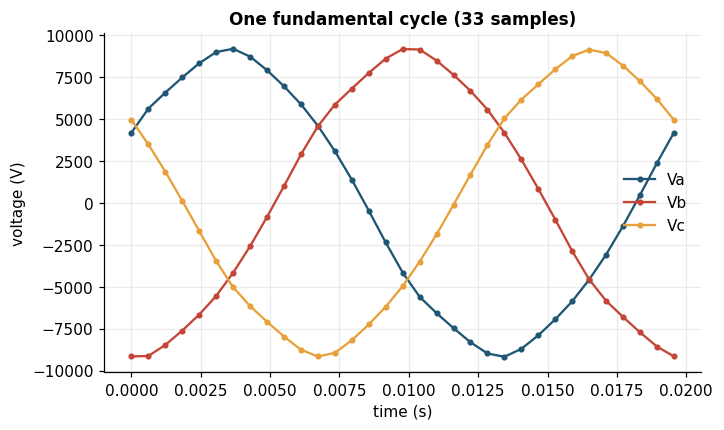

In [3]:
one_cycle = frame.iloc[: meta["samples_per_cycle"]]
fig, ax = plt.subplots(figsize=(7, 4))
for column in ("Va", "Vb", "Vc"):
    ax.plot(
        one_cycle["time_s"],
        one_cycle[column],
        color=palette(column),
        marker="o",
        ms=3,
        label=column,
    )
ax.set_xlabel("time (s)")
ax.set_ylabel("voltage (V)")
ax.set_title(f"One fundamental cycle ({meta['samples_per_cycle']} samples)")
ax.legend()
plt.show()

## Harmonics carry the sequence

Here is the trick this notebook leans on: in a balanced three-phase system the
harmonic orders are not sequence-neutral. Order $3m+1$ rotates the same way as
the fundamental (positive sequence), order $3m+2$ rotates against it (negative
sequence) and order $3m$ collapses into the zero sequence. So one way to read the
sequence content is to take the spectrum of each phase over a sliding cycle,
group it into integer harmonics and average the magnitudes by sequence. It is an
approximate reading, because it leans on that balanced-system pattern, but it is
a useful sanity check on the cleaner method in notebook 02.

In [4]:
harmonic_voltage = pd.read_parquet(ARTIFACTS / "harmonic_voltage.parquet")
harmonic_current = pd.read_parquet(ARTIFACTS / "harmonic_current.parquet")
sequence_means = (
    harmonic_voltage.groupby("sequence")["magnitude"].mean().reindex(["P", "N", "Z"]).round(1)
)
sequence_means.to_frame("mean voltage sequence magnitude")

,mean voltage sequence magnitude
sequence,
P,2127.6
N,1114.3
Z,660.9


The positive sequence dominates, as it must for a working supply, but the
negative and zero sequences are not negligible and they vary through the event.
Averaging the per-phase harmonic magnitudes by sequence and plotting them against
time gives a first look at how the imbalance evolves.

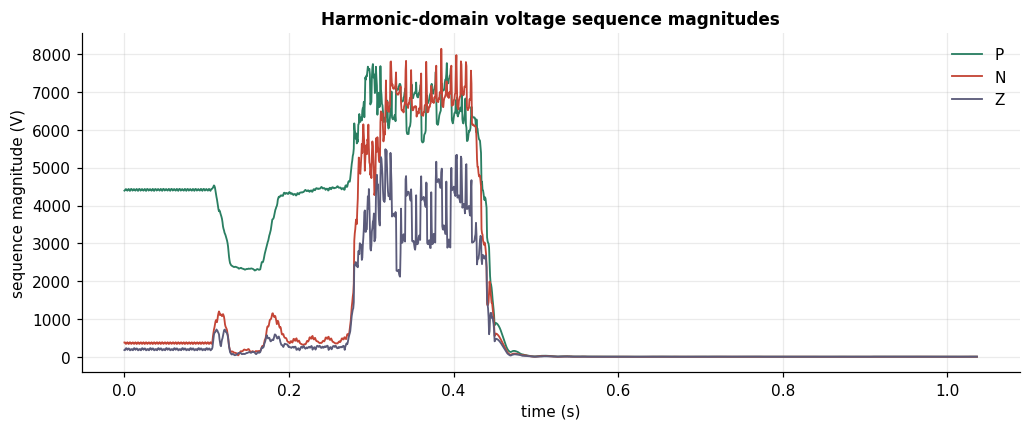

In [5]:
voltage_by_window = (
    harmonic_voltage.groupby(["time_s", "sequence"])["magnitude"].mean().reset_index()
)
fig, ax = plt.subplots(figsize=(11, 4))
for label in ("P", "N", "Z"):
    series = voltage_by_window[voltage_by_window["sequence"] == label]
    ax.plot(series["time_s"], series["magnitude"], color=palette(label), lw=1.2, label=label)
ax.set_xlabel("time (s)")
ax.set_ylabel("sequence magnitude (V)")
ax.set_title("Harmonic-domain voltage sequence magnitudes")
ax.legend()
save_figure(fig, "harmonic_voltage_sequences", ROOT / "reports" / "figures")
plt.show()

The current tells the same story on its own scale. Read together they say the
supply stays positive-sequence dominated throughout, with the imbalance riding on
top rather than taking over.

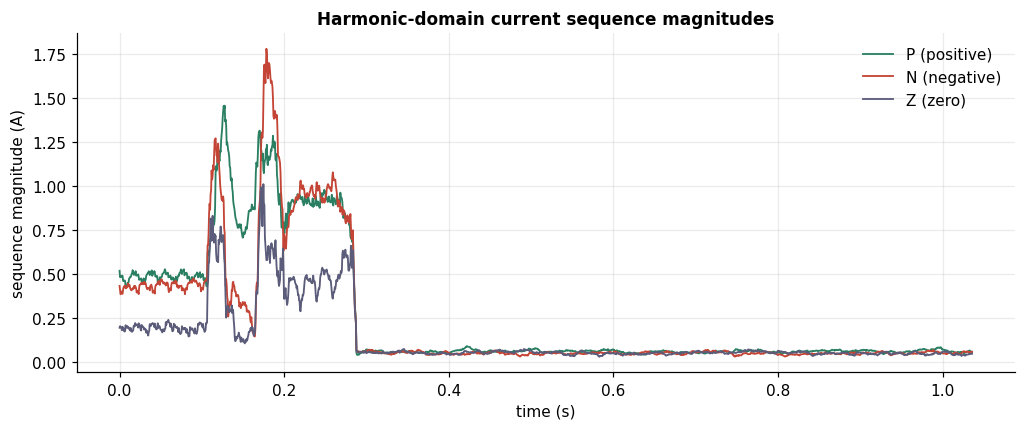

In [6]:
current_by_window = (
    harmonic_current.groupby(["time_s", "sequence"])["magnitude"].mean().reset_index()
)
fig, ax = plt.subplots(figsize=(11, 4))
plot_sequence_series(
    ax, current_by_window.assign(phase_kind="current"), "magnitude", "sequence magnitude (A)"
)
ax.set_title("Harmonic-domain current sequence magnitudes")
plt.show()

## Summary

- The telemetry is a balanced three-phase burst whose amplitudes drift over the
  event, the signature of a developing imbalance.
- Grouping the windowed spectrum into harmonics and labelling each by sequence
  recovers a positive-sequence-dominated picture with measurable negative and
  zero content.
- This harmonic view is approximate. Notebook 02 does it properly, estimating the
  phasors directly each cycle.